# BBreal
## Tanimoto similarity based for count fingeprints or real-value descriptors

Authors: 
-   Kenneth Lopez-Perez (klopezperez@chem.ufl.edu)
-   Ramon Alain Miranda-Quintana (quintana@chem.ufl.edu)


This notebook contains simple examples on how to use BBreal. A clustering algorithm based on Tanimoto similarity for count or real-value vectors. Note that this algorithm is not as efficient as BBlean because of the inherited overhead caused by the need of usage of float data types for the mathemical operations, but it is still a very efficient method.

Most functionalities of BitBirch have been implemented and displayed in this notebook.

### Imports

We are going to call imports mainly from the bbreal module. Auxiliary functions as count fingerprint generation are included in the utils module.

In [13]:
# Imports for fp generation, normalization and clustering
from iChem.bbreal import BBReal, set_merge, optimal_threshold_real
from iChem.utils import count_fps, real_fps, normalize_fps, load_smiles
from iChem.visualization.mol_images import smiles_to_grid_image

# Imports for visualization
from iChem.visualization.plots import clusters_pop_plot, clusters_pop_isim_real_plot
from iChem.iSIM.real import calculate_isim_real
from iChem.iSIM.sigma import stratified_sigma_real

# Import tracemalloc for memory profiling
import tracemalloc


# Fingerprint generation

In the first example of this notebook we are going to generate count fingerprints for a database of natural products (available at: https://mcule.com/database/).

In [2]:
smiles = load_smiles('../tests/data/mcule_natural_products.smi')

In [3]:
fps, invalid_smiles = count_fps(smiles,
                                fp_type='AP', # Use: 'AP", 'ECFP4', 'RDKIT', 'ECFP6', 'TT' or 'MACCS'
                                n_bits=1024,
                                return_invalid=True)

if invalid_smiles:
    print(f"Invalid SMILES found: {invalid_smiles}")
    print("Please check the input as problematic SMILES can lead to errors in downstream analysis.")

Normalization of the fingerprints is required before the clustering is done!

In [4]:
fps = normalize_fps(fps)

Let's check if the number of fingeprints and smiles matches.

In [5]:
if len(fps) != len(smiles):
    print("Warning: The number of valid fingerprints does not match the number of input SMILES.")
    print(f"Number of valid fingerprints: {len(fps)}")
    print(f"Nufrom iChem.bbreal.bbreal_old import BBReal as BBRealOldmber of input SMILES: {len(smiles)}")
else:
    print("All SMILES were successfully converted to fingerprints.")
    print(f"Number of valid fingerprints: {len(fps)}")

All SMILES were successfully converted to fingerprints.
Number of valid fingerprints: 23327


### Clustering

Now let's proceed with the clustering. To find the threshold, we are going to use the same guidelines for BitBirch best practices. We found in that study that a good threshold is the average + 3.5 standard deviations of the similarities. To get this, is not necessary to calculate the pairwise matrix, as with the iSIM and iSIM-sigma framework those values can be estimated with high accuracy. 

In [6]:
isim = calculate_isim_real(fps)
isim_sigma = stratified_sigma_real(fps)
print(f"Recommended threshold: {isim + 3.5*isim_sigma:.4f}")

Recommended threshold: 0.4770


The optimal threshold can be easily calculated with the optimal_threshold_real function. 

In [7]:
bb_threshold_real = optimal_threshold_real(fps,
                                           factor = 3.5)
print(f"Recommended threshold: {bb_threshold_real:.4f}")

Recommended threshold: 0.4770


In [8]:
tracemalloc.stop()
tracemalloc.start() # Start memory profiling
set_merge('diameter') # At the moment, only 'diameter' is offered as merging criterion

bbreal_model = BBReal(threshold=bb_threshold_real,
                          branching_factor=1024) # Branching factor can be changed. Too small gives lots of singletons, too big is slow.

bbreal_model.fit(fps)

print(f"Memory usage after fitting: {tracemalloc.get_traced_memory()[0] / 1e6:.2f} MB")
print(f"Peak memory usage during fitting: {tracemalloc.get_traced_memory()[1] / 1e6:.2f} MB")

Memory usage after fitting: 58.48 MB
Peak memory usage during fitting: 66.64 MB


### Analysis of clustering results

Let's take a look at the number of clusters, and some metrics about them.

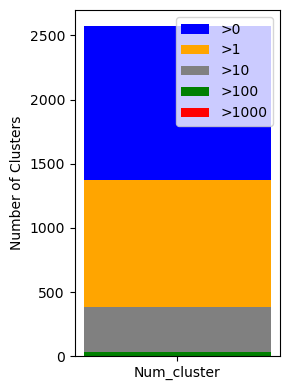

In [11]:
clustered_ids = bbreal_model.get_cluster_mol_ids()
clusters_pop_plot(clustered_ids)

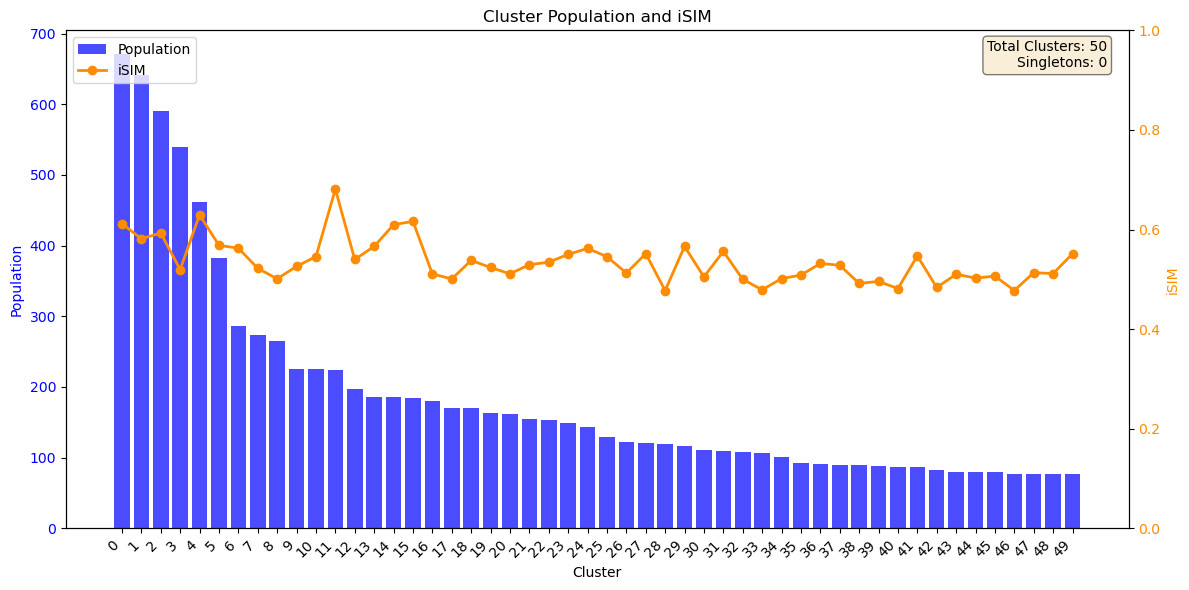

In [14]:
clusters_pop_isim_real_plot(bbreal_model,
                       top=50)

In [15]:
# We can use some refinement strategies to reduce the number of singletons.
# We can use an extra threshold to be more lenient in the merging, and we can shuffle the data to get different merges.
# Recluster in place will cluster already formed clusters in a new tree.


bbreal_model.recluster_inplace(iterations=5,
                               extra_threshold=stratified_sigma_real(fps)*0.5, # We recommend using 1 or 0.5 stds
                               shuffle=True,
                               verbose=True,
                               seed=42,
                               stop_early=True) # Function will stop if no merges are made in an iteration.

Iteration 1/5
  Current number of clusters: 2570
  Current number of singletons: 1196
Iteration 2/5
  Current number of clusters: 2255
  Current number of singletons: 978
Iteration 3/5
  Current number of clusters: 2212
  Current number of singletons: 930
Iteration 4/5
  Current number of clusters: 2205
  Current number of singletons: 924
Iteration 5/5
  Current number of clusters: 2203
  Current number of singletons: 920

Final Results:
  Final number of clusters: 2203
  Final number of singletons: 920


Let's take a look at the new cluster populations and metrics after the refinement.

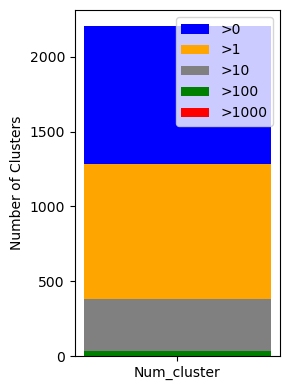

In [16]:
clusters_pop_plot(bbreal_model.get_cluster_mol_ids())

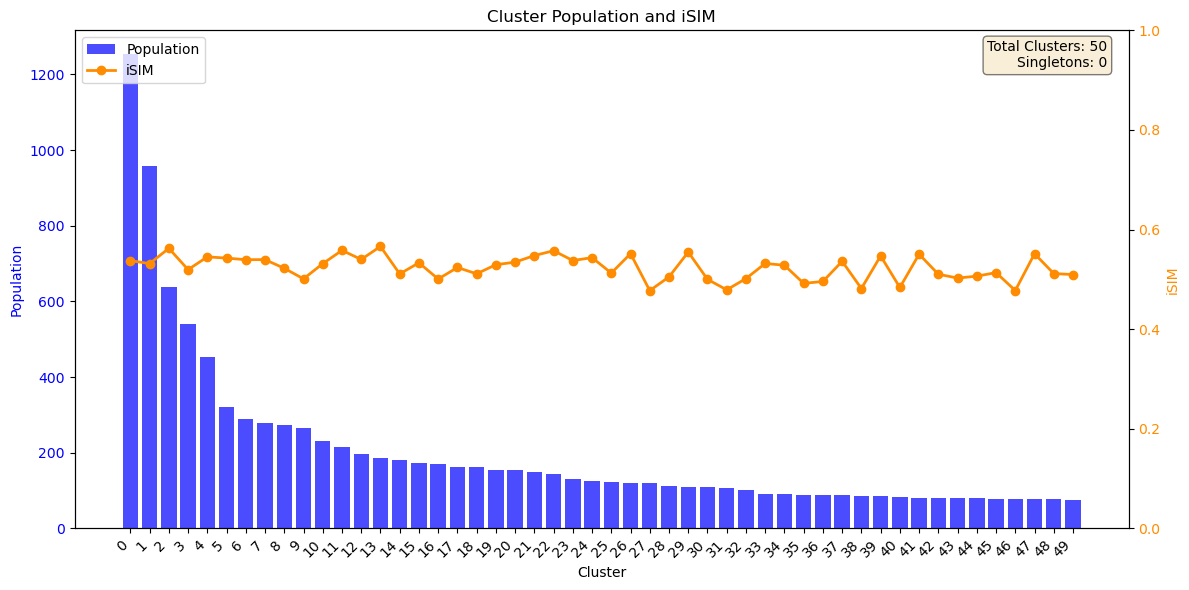

In [17]:
clusters_pop_isim_real_plot(bbreal_model,
                       top=50)

In [18]:
clusters = bbreal_model.get_cluster_mol_ids()

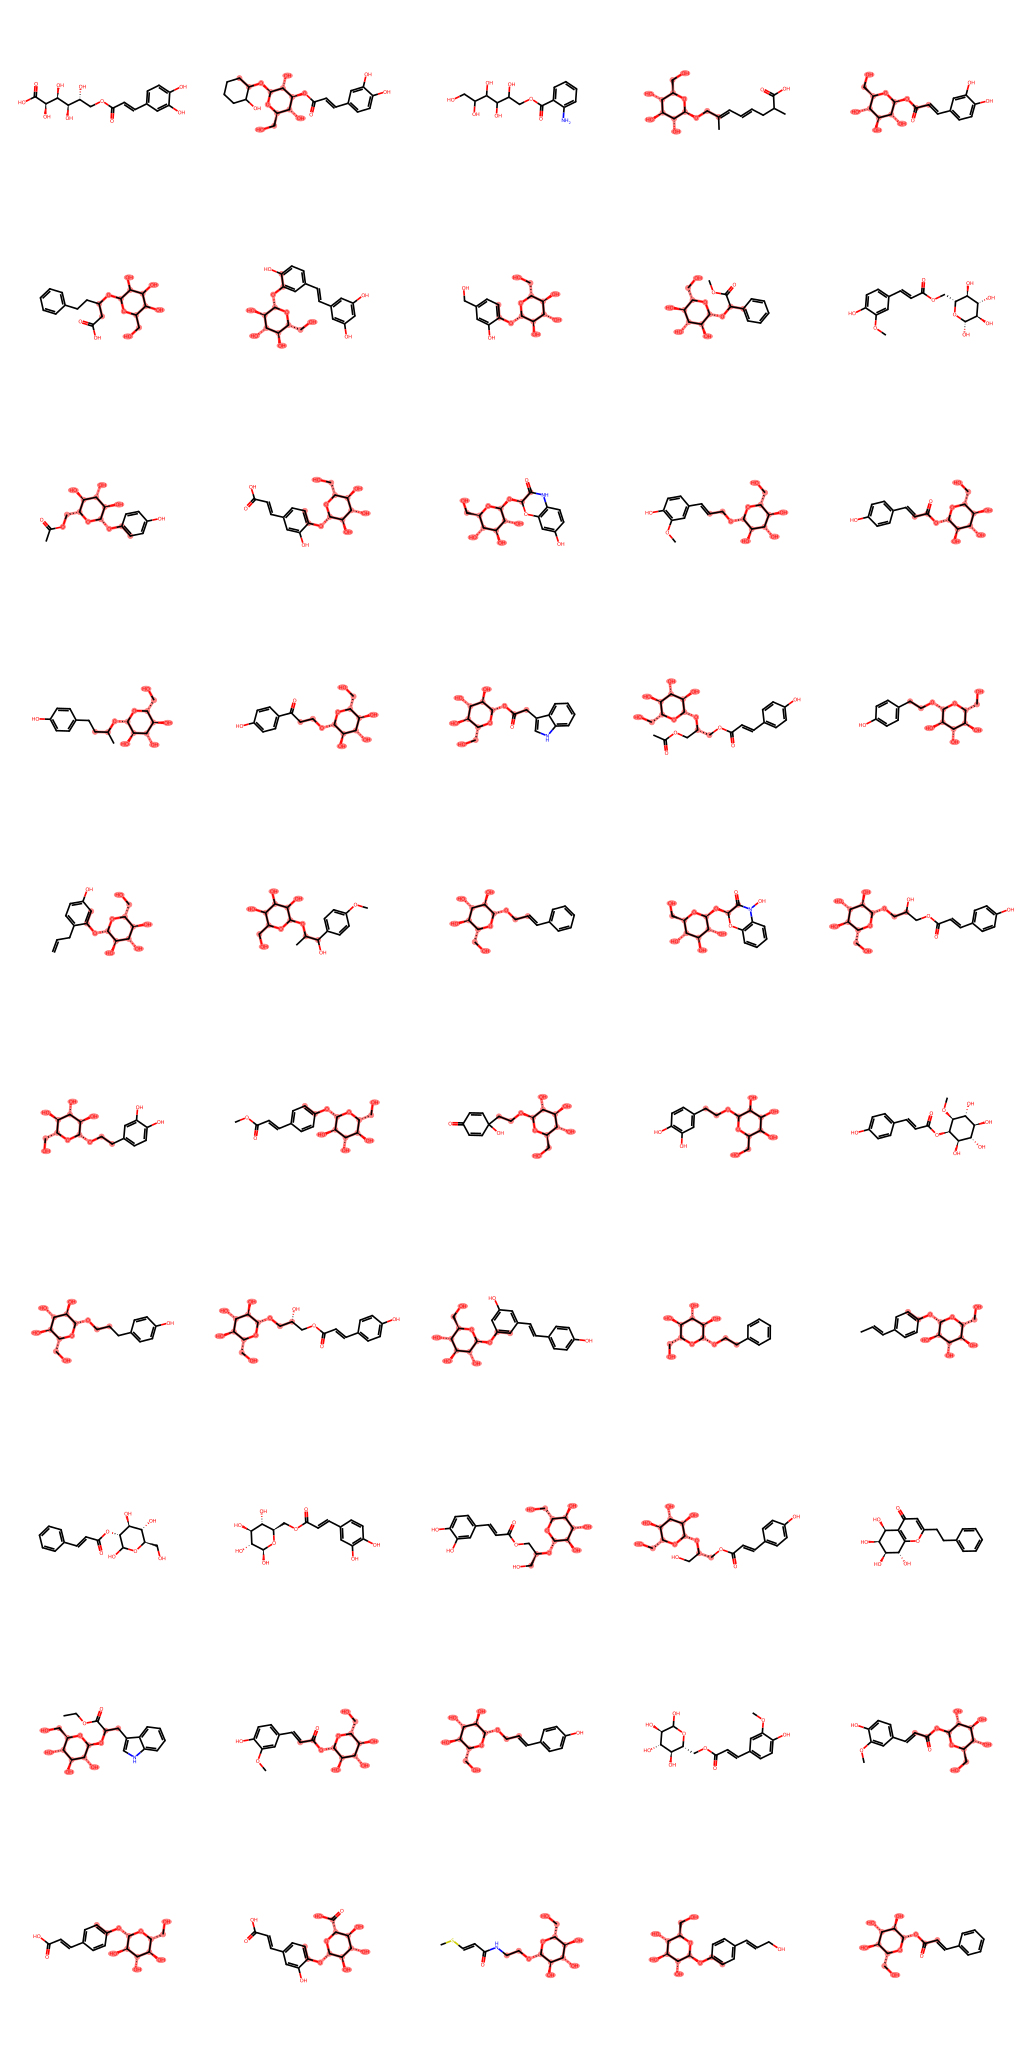

In [21]:
k = 67 # Change to the cluster you want to visualize
smiles_to_grid_image([smiles[i] for i in clusters[k]], MSC=True)